<a href="https://colab.research.google.com/github/ahmetefekaratas/nba-finals-eda/blob/main/nbafinals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NBA Finals & MVP Exploratory Data Analysis
**Author:** Ahmet Efe Karataş

This project explores historical NBA Finals and MVP records. The analysis covers data cleaning, univariate distributions of player attributes, franchise dominance, and final series outcomes.

- **Data Source:** [Kaggle Dataset](https://www.kaggle.com/datasets/rifkaregmi/nba-player-stats)
- **Timeframe:** 1951 – 2018 (Championships outside this range, such as 1949–1950 and post-2018, are excluded).

In [1]:
from google.colab import drive
import re
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


drive.mount("/content/drive")

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")


nba = pd.read_csv(
   "/content/drive/MyDrive/NBA Finals and MVP.csv", encoding="latin1")



nba.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Year,Western Champion,Eastern Champion,Result,NBA Champion,NBA Vice-Champion,Final Sweep ?,MVP Name,MVP Height (m),MVP Height (ft),MVP Position,MVP Team,MVP Nationality,MVP status
0,1951.0,Rochester Royals,New York Knicks,43,Rochester Royals,New York Knicks,False,Ed Macauley,2.03,6.08,Center,Boston Celtics,US,Not reached Final
1,1952.0,Minneapolis Lakers,New York Knicks,43,Minneapolis Lakers,New York Knicks,False,Paul Arizin,1.93,6.04,Forward,Philadelphia Warriors,US,Not reached Final
2,1953.0,Minneapolis Lakers,New York Knicks,41,Minneapolis Lakers,New York Knicks,False,George Mikan,2.08,6.82,Center,Minneapolis Lakers,US,Not reached Final
3,1954.0,Minneapolis Lakers,Syracuse Nationals,43,Minneapolis Lakers,Syracuse Nationals,False,B. Cousy,1.85,6.07,Guard,Boston Celtics,US,Champion
4,1955.0,Fort Wayne Pistons,Syracuse Nationals,34,Syracuse Nationals,Fort Wayne Pistons,False,B. Pettit,2.06,6.76,Forward,Saint Louis Hawks,US,Not reached Final


In [2]:
print(nba.shape)
nba.info()

(69, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               68 non-null     float64
 1   Western Champion   68 non-null     object 
 2   Eastern Champion   68 non-null     object 
 3   Result             68 non-null     object 
 4   NBA Champion       68 non-null     object 
 5   NBA Vice-Champion  68 non-null     object 
 6   Final Sweep ?      68 non-null     object 
 7   MVP Name           68 non-null     object 
 8   MVP Height (m)     68 non-null     float64
 9   MVP Height (ft)    68 non-null     float64
 10  MVP Position       68 non-null     object 
 11  MVP Team           68 non-null     object 
 12  MVP Nationality    68 non-null     object 
 13  MVP status         69 non-null     object 
dtypes: float64(3), object(11)
memory usage: 7.7+ KB


In [3]:
nba[nba['Year'].isna()]

,Year,Western Champion,Eastern Champion,Result,NBA Champion,NBA Vice-Champion,Final Sweep ?,MVP Name,MVP Height (m),MVP Height (ft),MVP Position,MVP Team,MVP Nationality,MVP status
68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not reached Final


## Data Cleaning

Initial inspection using `info()` revealed a missing row containing null values across season metrics. We identify this invalid entry using boolean masking (`isna()`), remove it from the dataset, and convert the `Year` column to integer format for consistency.

In [4]:

nba = nba.dropna(subset=["Year"]).copy()

nba["Year"] = nba["Year"].astype(int)

print(nba.shape)

(68, 14)


## 1. Univariate Analysis: MVP Position Distribution

We analyze which basketball positions dominate the NBA Finals MVP awards using value counts and a bar chart.

MVP Position
Center     28
Forward    20
Guard      20
Name: count, dtype: int64


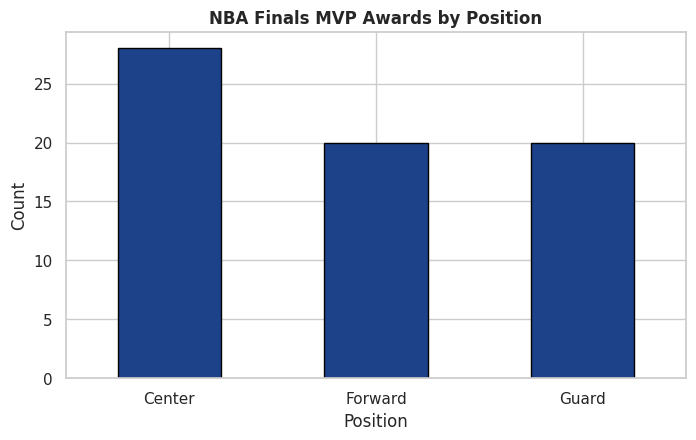

In [5]:

pos_counts = nba['MVP Position'].value_counts()
print(pos_counts)


plt.figure(figsize=(8, 4.5))
pos_counts.plot(kind='bar', color='#1d428a', edgecolor='black')
plt.title('NBA Finals MVP Awards by Position', fontsize=12, fontweight='bold')
plt.xlabel('Position')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

**Key Insight:**
Centers have historically dominated the Finals MVP award with 28 selections, reflecting the traditional "big man" era of basketball. Forwards and Guards share the remaining awards equally with 20 selections each.

## 2. Univariate Analysis: MVP Height Distribution (Mean vs. Median)

We examine the distribution of MVP heights (in meters), comparing the mean and median to observe potential skewness in the data.

Mean Height:   2.05 m
Median Height: 2.06 m


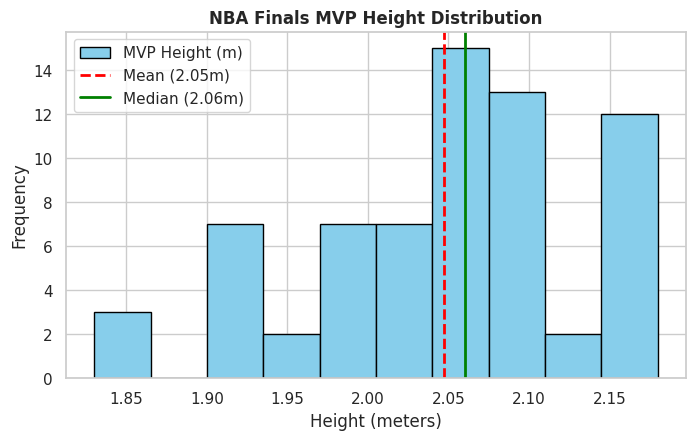

In [6]:

mean_h = nba['MVP Height (m)'].mean()
median_h = nba['MVP Height (m)'].median()

print(f"Mean Height:   {mean_h:.2f} m")
print(f"Median Height: {median_h:.2f} m")


plt.figure(figsize=(8, 4.5))
nba['MVP Height (m)'].plot(kind='hist', bins=10, color='skyblue', edgecolor='black')

plt.axvline(mean_h, color='red', linestyle='--', linewidth=2, label=f'Mean ({mean_h:.2f}m)')
plt.axvline(median_h, color='green', linestyle='-', linewidth=2, label=f'Median ({median_h:.2f}m)')

plt.title('NBA Finals MVP Height Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Height (meters)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**Key Insight:**
The mean height (2.05 m) and median height (2.06 m) are nearly identical, indicating a symmetrical distribution without extreme outliers pulling the average. The concentration around 2.05–2.10 m aligns with the heavy presence of Centers and Power Forwards among Finals MVPs.

## 3. Bivariate Analysis: Regular Season MVP Success & Finals Outcomes

We investigate the relationship between winning the regular season MVP award and playoff success: whether the MVP won the championship, reached the finals but lost, or failed to reach the finals entirely.

                   Count  Percentage (%)
MVP status                              
Not reached Final     35           51.47
Champion              24           35.29
Vice-Champion          9           13.24


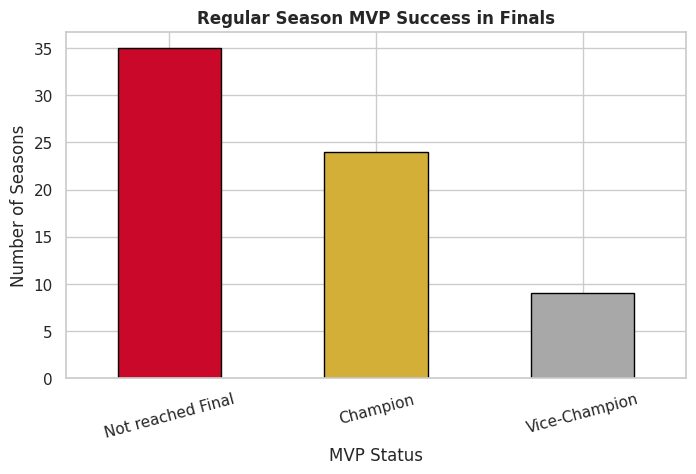

In [7]:
mvp_status_counts = nba['MVP status'].value_counts()
mvp_status_pct = nba['MVP status'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame(
    {'Count': mvp_status_counts, 'Percentage (%)': mvp_status_pct.round(2)}
)
print(summary_df)

plt.figure(figsize=(8, 4.5))
mvp_status_counts.plot(
    kind='bar', color=['#c9082a', '#d4af37', '#a8a8a8'], edgecolor='black'
)
plt.title('Regular Season MVP Success in Finals', fontsize=12, fontweight='bold')
plt.xlabel('MVP Status')
plt.ylabel('Number of Seasons')
plt.xticks(rotation=15)
plt.show()

**Key Insight:**
More than half of the regular season MVPs (51.47%) failed to even reach the NBA Finals. Only 35.29% went on to win the championship in the same year, demonstrating that individual regular season dominance does not guarantee postseason team success.

## 4. Franchise Dominance: All-Time NBA Championships

We analyze franchise dominance in NBA Finals history by evaluating the distribution of championships won by the most successful teams.

NBA Champion
Boston Celtics           17
Los Angeles Lakers       11
Chicago Bulls             6
San Antonio Spurs         5
Golden State Warriors     4
Detroit Pistons           3
Miami Heat                3
Minneapolis Lakers        3
Philadelphia 76ers        2
Houston Rockets           2
Name: count, dtype: int64


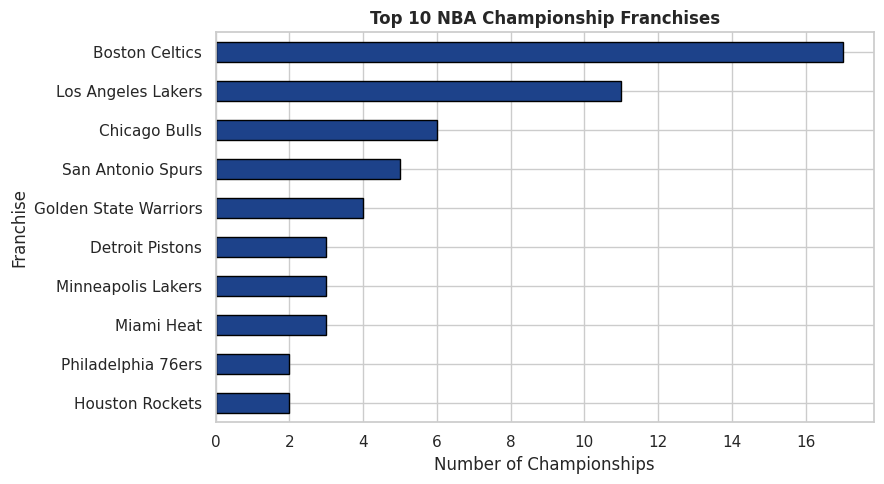

In [8]:
top_champions = nba['NBA Champion'].value_counts().head(10)
print(top_champions)

plt.figure(figsize=(9, 5))
top_champions.sort_values().plot(kind='barh', color='#1d428a', edgecolor='black')
plt.title('Top 10 NBA Championship Franchises', fontsize=12, fontweight='bold')
plt.xlabel('Number of Championships')
plt.ylabel('Franchise')
plt.tight_layout()
plt.show()

**Key Insight:**
Boston Celtics and the Lakers franchise heavily dominate historical championships. Note that the Lakers appear split between their Los Angeles and Minneapolis eras in the raw data, showing how data naming conventions can fragment a single franchise's historical legacy.

## 5. Finals Competitiveness: Distribution of Series Lengths

We analyze how competitive NBA Finals series have been historically by calculating the total number of games played in each series (ranging from 4-game sweeps to 7-game thrillers).

        Finals Count  Percentage (%)
Result                              
4                  9           13.24
5                 16           23.53
6                 24           35.29
7                 19           27.94


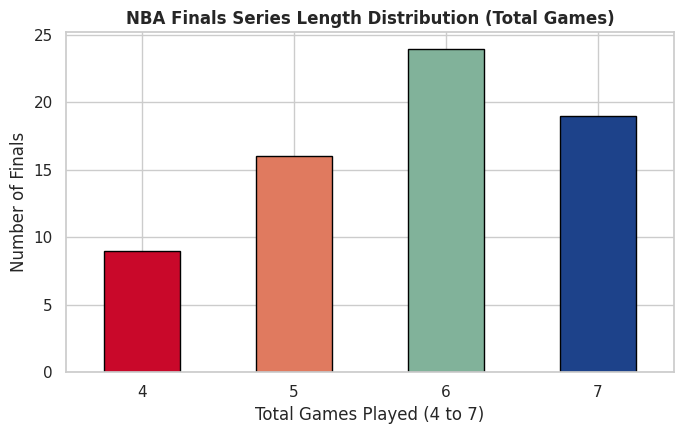

In [9]:


games_played = nba['Result'].dropna().apply(
    lambda x: sum(map(int, re.findall(r'\d+', str(x)))) if len(re.findall(r'\d+', str(x))) >= 2 else None
)

series_counts = games_played.value_counts().sort_index()
series_pct = (games_played.value_counts(normalize=True).sort_index() * 100).round(2)

print(pd.DataFrame({'Finals Count': series_counts, 'Percentage (%)': series_pct}))

colors = ['#c9082a', '#e07a5f', '#81b29a', '#1d428a']

plt.figure(figsize=(7, 4.5))
series_counts.plot(kind='bar', color=colors[:len(series_counts)], edgecolor='black')
plt.title('NBA Finals Series Length Distribution (Total Games)', fontsize=12, fontweight='bold')
plt.xlabel('Total Games Played (4 to 7)')
plt.ylabel('Number of Finals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Key Insight:**

NBA Finals are historically highly competitive:

- **63.23% Extended Series:**
  Over 63% of Finals went to 6 or 7 games.

- **27.94% Game 7 Thrillers:**
  Nearly 28% of matchups reached a decisive Game 7.

- **13.24% Rare Sweeps:**
  One-sided 4-0 sweeps are remarkably uncommon.



## 6. Historical MVP Origins: Heavy US Dominance

An examination of MVP player nationalities from 1951 to 2018, showing how heavily American players dominated the individual award prior to the modern international era.

,Year,MVP Name,MVP Nationality,MVP Team
43,1994,H. Olajuwon,Nigeria,Houston Rockets
54,2005,S. Nash,Canada,Phoenix Suns
55,2006,S. Nash,Canada,Phoenix Suns
56,2007,D. Nowitzki,Germany,Dallas Mavericks


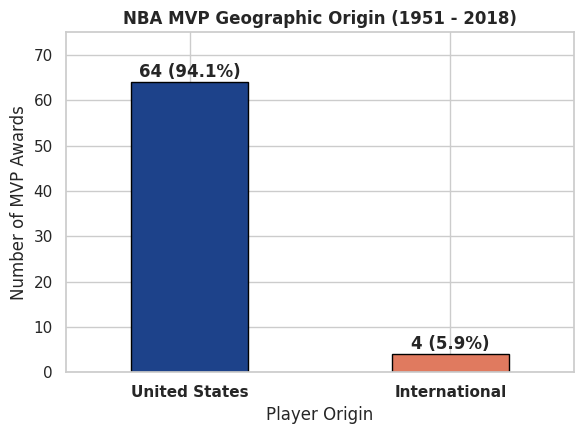

In [10]:


valid_nba = nba.dropna(subset=['MVP Name', 'MVP Nationality']).copy()

valid_nba['Origin'] = valid_nba['MVP Nationality'].apply(
    lambda x: 'US' if str(x).strip().upper() == 'US' else 'International'
)

origin_counts = valid_nba['Origin'].value_counts()

intl_mvps = valid_nba[valid_nba['Origin'] == 'International'][['Year', 'MVP Name', 'MVP Nationality', 'MVP Team']].copy()
intl_mvps['Year'] = intl_mvps['Year'].astype(int)

display(intl_mvps)

plt.figure(figsize=(6, 4.5))
colors = ['#1d428a', '#e07a5f']
ax = origin_counts.plot(kind='bar', color=colors, edgecolor='black', width=0.45)

for p in ax.patches:
    pct = (p.get_height() / len(valid_nba) * 100).round(1)
    ax.annotate(
        f"{int(p.get_height())} ({pct}%)",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center',
        xytext=(0, 7), textcoords='offset points',
        fontweight='bold'
    )

plt.title('NBA MVP Geographic Origin (1951 - 2018)', fontsize=12, fontweight='bold')
plt.xlabel('Player Origin')
plt.ylabel('Number of MVP Awards')
plt.xticks(ticks=[0, 1], labels=['United States', 'International'], rotation=0, fontweight='bold')
plt.ylim(0, 75)
plt.tight_layout()
plt.show()

**Key Insight:**

The MVP award was historically dominated almost entirely by American players:

- **94.1% Domestic Dominance:**
  64 out of 68 MVPs were American players.

- **Only 4 International MVP Honors:**
  - 1994: Hakeem Olajuwon (Nigeria - Houston Rockets)
  - 2005: Steve Nash (Canada - Phoenix Suns)
  - 2006: Steve Nash (Canada - Phoenix Suns)
  - 2007: Dirk Nowitzki (Germany - Dallas Mavericks)

## 7. Summary & Final Insights

A simple overview of all 6 analytical sections from the 1951–2018 dataset:

- **1. MVP Positions:**
  Centers and Forwards historically won the most MVP awards, showing the value of big men in that era[cite: 8].

- **2. MVP Physical Profiles:**
  The average height was around 2.05 meters, proving that the league strongly rewarded tall and versatile athletes[cite: 9].

- **3. Regular Season MVP vs. Title:**
  More than 51% of regular season MVPs did not reach the Finals, showing that individual awards do not guarantee a championship[cite: 10].

- **4. Franchise Dominance:**
  Championships were mostly won by top dynasties, led mainly by the Boston Celtics and Los Angeles Lakers[cite: 11].

- **5. Finals Competitiveness:**
  Over 63% of Finals series went to 6 or 7 games, while clean 4-0 sweeps were very rare at only 13.24%.

- **6. Geographic Origins:**
  US players won 94.1% of MVP trophies, showing an almost total American dominance throughout this era[cite: 7].

---
**Profiles:** [GitHub](https://github.com/ahmetefekaratas) | [Kaggle](https://www.kaggle.com/aefekaratas)